In [ ]:
print("Hello World")
print("Hello W")

Hello World


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("../data/loan_data.csv")
df.head()

,Age,Income,Loan_Amount,Loan_Term,Credit_Score,Employment_Years,Dependents,Education,Self_employed,Property_Area,Marital_Status,PreviousDefault,Loan_Status
0,56,106654,43255,25,528,36,3,phd,No,semiurban,married,no,Rejected
1,69,108177,6624,58,563,1,0,high school,No,rural,single,no,Rejected
2,46,92902,34706,54,786,23,4,bachelor,No,rural,married,no,Approved
3,32,112172,9176,52,651,14,1,high school,No,urban,married,no,Approved
4,60,35630,34529,28,741,32,1,master,No,semiurban,single,yes,Rejected


In [5]:
X = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
categorical_cols = X.select_dtypes(include="str").columns
numerical_cols = X.select_dtypes(include="number").columns

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",num_pipeline,numerical_cols),
    ("cat",cat_pipeline,categorical_cols)
])

model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(n_estimators=100,random_state=42,class_weight="balanced"))
    
])

In [21]:
print(model.classes_)

['Approved' 'Rejected']


In [12]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.4f}")
cr = classification_report(y_test,y_pred)
print(f"Classification report: {cr}")

Accuracy: 0.9969
Classification report:               precision    recall  f1-score   support

    Approved       1.00      0.99      0.99       488
    Rejected       1.00      1.00      1.00      1112

    accuracy                           1.00      1600
   macro avg       1.00      0.99      1.00      1600
weighted avg       1.00      1.00      1.00      1600



In [17]:
import joblib

joblib.dump(model,"../model/loan_approval.pkl")
joblib.dump(accuracy,"../model/accuracy.pkl")
print("Model saved successfully")
print("Accuracy saved successfully")

Model saved successfully
Accuracy saved successfully


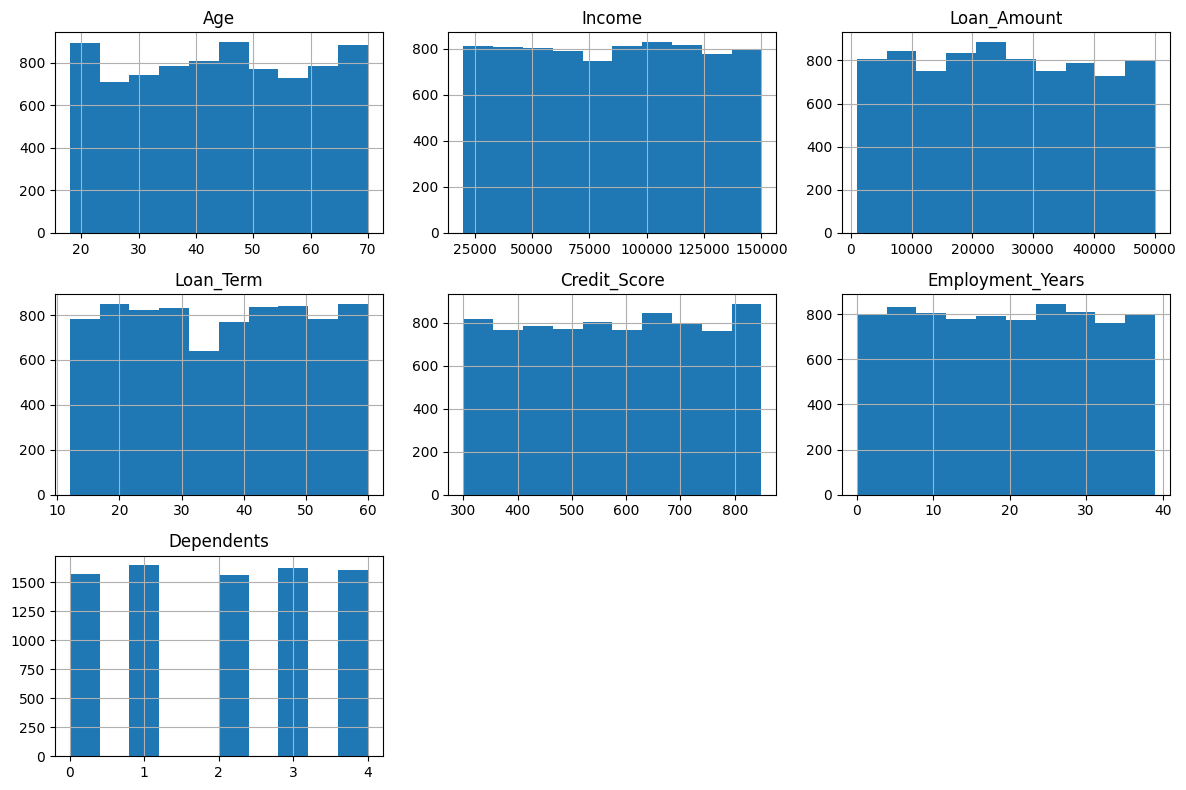

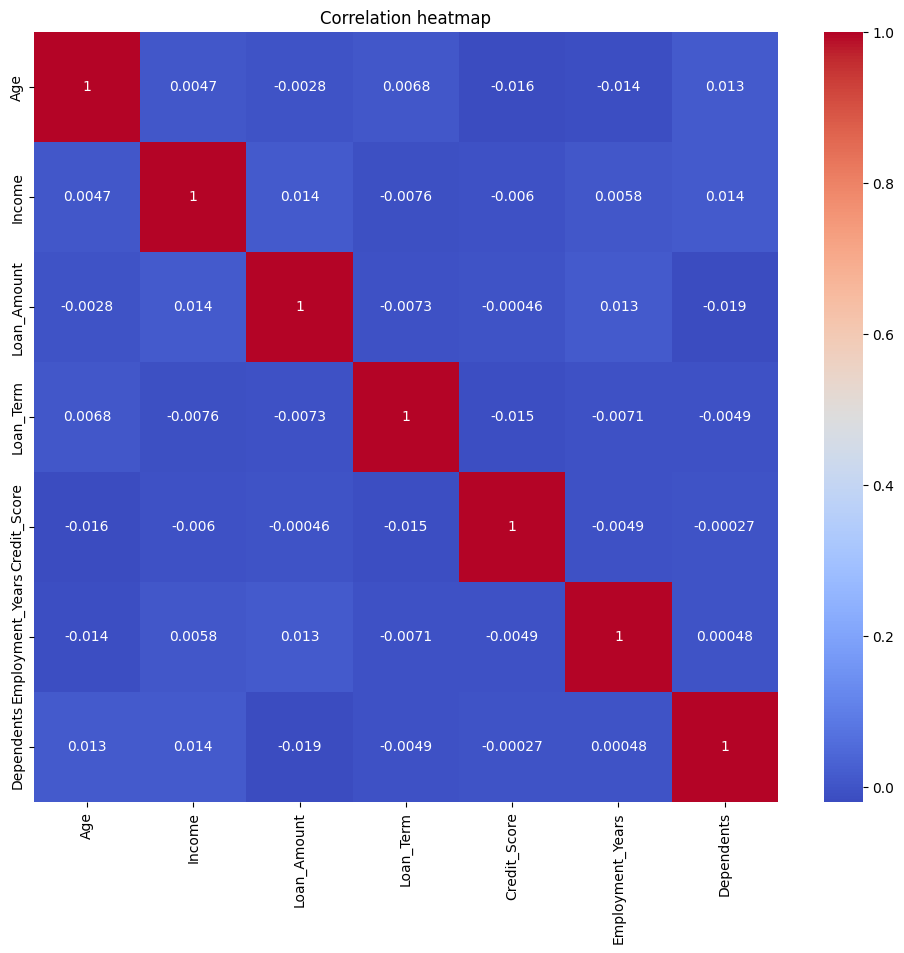

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

df[numerical_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,10))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation heatmap")
plt.show()
